# Visualization: What/Where Brain Regions & GT vs Pred Comparison

**Tasks:**
1. Per-stream analysis with Where (blue) and What (red) regions
2. Show GT fMRI on anatomical
3. Show Pred fMRI on anatomical
4. Show overlap (purple) vs miss-overlap (green)

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns
import json
from scipy.stats import pearsonr
import nibabel as nib
from nilearn import plotting

plt.style.use('seaborn-v0_8-whitegrid')
print("Ready!")

Ready!


## 1. Load Data & Model

In [2]:
# Load brain atlas
roi_mapping = np.load('../dataset/nsd/metadata/subj01_roi_mapping.npz')
with open('../dataset/nsd/metadata/roi_labels.json', 'r') as f:
    roi_labels = json.load(f)

streams = roi_mapping['streams']
stream_names = {int(k): v for k, v in roi_labels['streams'].items()}

# Create mapping
stream_to_voxels = {}
for sid, sname in stream_names.items():
    stream_to_voxels[sname] = np.where(streams == sid)[0]
    print(f"{sname}: {len(stream_to_voxels[sname])} voxels")

Early: 5463 voxels
Midventral: 986 voxels
Midlateral: 834 voxels
Lateral: 856 voxels
Ventral: 3630 voxels
Parietal: 2375 voxels


In [3]:
# Load NIfTI brain data
nsd_roi_path = '/mnt/HDD/dataset/NSD_raw/nsddata/ppdata/subj01/func1pt8mm/roi/'
streams_nii = nib.load(nsd_roi_path + 'streams.nii.gz')
streams_data = streams_nii.get_fdata()

# Load anatomical template
anat_path = '/mnt/HDD/dataset/NSD_raw/nsddata/ppdata/subj01/anat/T1_1pt8mm.nii.gz'
try:
    anat_nii = nib.load(anat_path)
    anat_data = anat_nii.get_fdata()
    print(f"Anatomical shape: {anat_data.shape}")
except:
    print("Warning: Could not load anatomical image, using streams as background")
    anat_nii = None
    anat_data = None

print(f"Streams NIfTI shape: {streams_data.shape}")
print(f"Unique stream values: {np.unique(streams_data)}")

Streams NIfTI shape: (81, 104, 83)
Unique stream values: [-1.  0.  1.  2.  3.  4.  5.  6.  7.]


In [4]:
# Load model
from model.hierarchical_v3 import HierarchicalARM_V3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HierarchicalARM_V3(
    cls_dim=768, patch_dim=768, num_patches=256,
    fmri_dim=15724, voxels_per_cluster=30,
).to(device)

# Load trained checkpoint
checkpoint_path = '../checkpoints/hierarchical_v3_subj01_30/best_stage1.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)

if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
elif 'state_dict' in checkpoint:
    model.load_state_dict(checkpoint['state_dict'])
else:
    model.load_state_dict(checkpoint)

model.eval()
print(f"Model loaded: {model.num_rois} ROIs, {model.voxels_per_cluster} voxels/ROI")

DualStreamMambaStage1: 15724 voxels → 524 ROIs (30 voxels/ROI, 4 remainder)
Model loaded: 524 ROIs, 30 voxels/ROI


In [5]:
# Load test data
cls_test = np.load('../dataset/nsd/embeddings_mindeye2/dinov2_test_sub01.npy')
patches_test = np.load('../dataset/nsd/embeddings_patches/dinov2_patches_test_sub01.npy')[:, 1:, :]
gt_fmri = np.load('../dataset/nsd/mixed_1000_sub01/test_fmri.npy')

print(f"Samples: {len(cls_test)}")
print(f"CLS shape: {cls_test.shape}")
print(f"Patches shape: {patches_test.shape}")
print(f"GT fMRI shape: {gt_fmri.shape}")

Samples: 982
CLS shape: (982, 768)
Patches shape: (982, 256, 768)
GT fMRI shape: (982, 15724)


In [ ]:
# Extract what/where outputs and full prediction
def extract_branches(model, cls_token, patch_tokens):
    stage1 = model.stage1
    
    # What branch
    what_x = stage1.what_proj(cls_token).unsqueeze(1)
    what_x = stage1.what_norm(what_x)
    with torch.amp.autocast('cuda', enabled=False):
        what_x = what_x.float()
        for m in stage1.what_mamba:
            what_x = what_x + torch.clamp(m(what_x), -10, 10)
    what_roi = stage1.what_head(what_x.squeeze(1))
    
    # Where branch
    where_x = stage1.where_proj(patch_tokens) + stage1.where_pos_embed
    where_x = stage1.where_norm(where_x)
    with torch.amp.autocast('cuda', enabled=False):
        where_x = where_x.float()
        for m in stage1.where_mamba:
            where_x = where_x + torch.clamp(m(where_x), -10, 10)
    where_roi = stage1.where_head(stage1.where_pool(where_x.mean(dim=1)))
    
    return what_roi, where_roi

def roi_to_voxel(roi_pred, n_rois, vpc, total_voxels=15724):
    """Expand ROI predictions to voxel-level by repeating each ROI value."""
    batch_size = roi_pred.shape[0]
    voxel_pred = np.zeros((batch_size, total_voxels))
    for i in range(n_rois):
        start = i * vpc
        end = min((i + 1) * vpc, total_voxels)
        voxel_pred[:, start:end] = roi_pred[:, i:i+1]
    return voxel_pred

# Run inference
num_samples = min(200, len(cls_test))
all_what, all_where, all_pred_roi = [], [], []

with torch.no_grad():
    for i in range(0, num_samples, 16):
        end = min(i+16, num_samples)
        cls_b = torch.tensor(cls_test[i:end]).to(device)
        pat_b = torch.tensor(patches_test[i:end]).to(device)
        
        # Get branches
        w, wh = extract_branches(model, cls_b, pat_b)
        all_what.append(w.cpu().numpy())
        all_where.append(wh.cpu().numpy())
        
        # Get full prediction (ROI-level)
        pred, _ = model(cls_b, pat_b)
        all_pred_roi.append(pred.cpu().numpy())

all_what = np.concatenate(all_what)       # [N, 524]
all_where = np.concatenate(all_where)     # [N, 524]
all_pred_roi = np.concatenate(all_pred_roi)  # [N, 524]
gt_subset = gt_fmri[:num_samples]         # [N, 15724]

# Expand ROI predictions to voxel-level
vpc = model.voxels_per_cluster
n_rois = model.num_rois
all_pred = roi_to_voxel(all_pred_roi, n_rois, vpc)  # [N, 15724]

print(f"what: {all_what.shape}, where: {all_where.shape}")
print(f"pred_roi: {all_pred_roi.shape} -> pred_voxel: {all_pred.shape}")
print(f"gt: {gt_subset.shape}")

In [7]:
# Compute correlations
vpc = model.voxels_per_cluster
n_rois = model.num_rois

# GT ROI means
gt_roi = np.zeros((num_samples, n_rois))
for i in range(n_rois):
    gt_roi[:, i] = gt_subset[:, i*vpc:(i+1)*vpc].mean(axis=1)

# Correlation per ROI
what_corr = np.array([pearsonr(all_what[:, i], gt_roi[:, i])[0] for i in range(n_rois)])
where_corr = np.array([pearsonr(all_where[:, i], gt_roi[:, i])[0] for i in range(n_rois)])

what_corr = np.nan_to_num(what_corr)
where_corr = np.nan_to_num(where_corr)

# Map ROI-level corr to voxel-level
what_voxel_corr = np.zeros(15724)
where_voxel_corr = np.zeros(15724)

for i in range(n_rois):
    what_voxel_corr[i*vpc:(i+1)*vpc] = what_corr[i]
    where_voxel_corr[i*vpc:(i+1)*vpc] = where_corr[i]

print(f"What corr mean: {what_corr.mean():.4f}")
print(f"Where corr mean: {where_corr.mean():.4f}")

What corr mean: 0.0060
Where corr mean: -0.0005


## 2. Per-Stream Visualization: What (Red) vs Where (Blue)

In [8]:
# Per-stream analysis
stream_results = []
for sname, voxels in stream_to_voxels.items():
    if len(voxels) == 0:
        continue
    what_mean = what_voxel_corr[voxels].mean()
    where_mean = where_voxel_corr[voxels].mean()
    diff = what_mean - where_mean
    better = "What" if diff > 0 else "Where"
    stream_results.append({
        'stream': sname,
        'what_corr': what_mean,
        'where_corr': where_mean,
        'diff': diff,
        'better': better,
        'n_voxels': len(voxels)
    })

stream_results = sorted(stream_results, key=lambda x: x['diff'], reverse=True)

print("Per-Stream Analysis:")
print("="*60)
for r in stream_results:
    symbol = "RED (What)" if r['better'] == 'What' else "BLUE (Where)"
    print(f"{r['stream']:<12}: {symbol:<15} (diff={r['diff']:+.4f})")

Per-Stream Analysis:
Ventral     : RED (What)      (diff=+0.0450)
Midlateral  : RED (What)      (diff=+0.0350)
Parietal    : RED (What)      (diff=+0.0214)
Lateral     : RED (What)      (diff=+0.0212)
Midventral  : RED (What)      (diff=+0.0025)
Early       : BLUE (Where)    (diff=-0.0443)


In [9]:
# Stream ID mapping (from NSD documentation)
stream_id_to_name = {
    1: 'Early',
    2: 'Midventral', 
    3: 'Midlateral',
    4: 'Lateral',
    5: 'Ventral',
    6: 'Parietal'
}

# Create stream to result mapping
stream_to_result = {r['stream']: r for r in stream_results}

# Create What/Where dominance volume
# What dominant = positive (Red)
# Where dominant = negative (Blue)
dominance_volume = np.zeros_like(streams_data, dtype=np.float32)

for stream_id, stream_name in stream_id_to_name.items():
    if stream_name in stream_to_result:
        mask = streams_data == stream_id
        diff_val = stream_to_result[stream_name]['diff']
        dominance_volume[mask] = diff_val
        print(f"Stream {stream_id} ({stream_name}): diff={diff_val:+.4f}")

dominance_nii = nib.Nifti1Image(dominance_volume, streams_nii.affine, streams_nii.header)
print(f"\nDominance volume created: {dominance_volume.shape}")

Stream 1 (Early): diff=-0.0443
Stream 2 (Midventral): diff=+0.0025
Stream 3 (Midlateral): diff=+0.0350
Stream 4 (Lateral): diff=+0.0212
Stream 5 (Ventral): diff=+0.0450
Stream 6 (Parietal): diff=+0.0214

Dominance volume created: (81, 104, 83)


In [10]:
# Create separate What and Where volumes for RGB visualization
what_volume = np.zeros_like(streams_data, dtype=np.float32)
where_volume = np.zeros_like(streams_data, dtype=np.float32)

for stream_id, stream_name in stream_id_to_name.items():
    if stream_name in stream_to_result:
        mask = streams_data == stream_id
        r = stream_to_result[stream_name]
        if r['better'] == 'What':
            # Red regions - What dominant
            what_volume[mask] = abs(r['diff'])
        else:
            # Blue regions - Where dominant
            where_volume[mask] = abs(r['diff'])

print(f"What volume max: {what_volume.max():.4f}")
print(f"Where volume max: {where_volume.max():.4f}")

What volume max: 0.0450
Where volume max: 0.0443


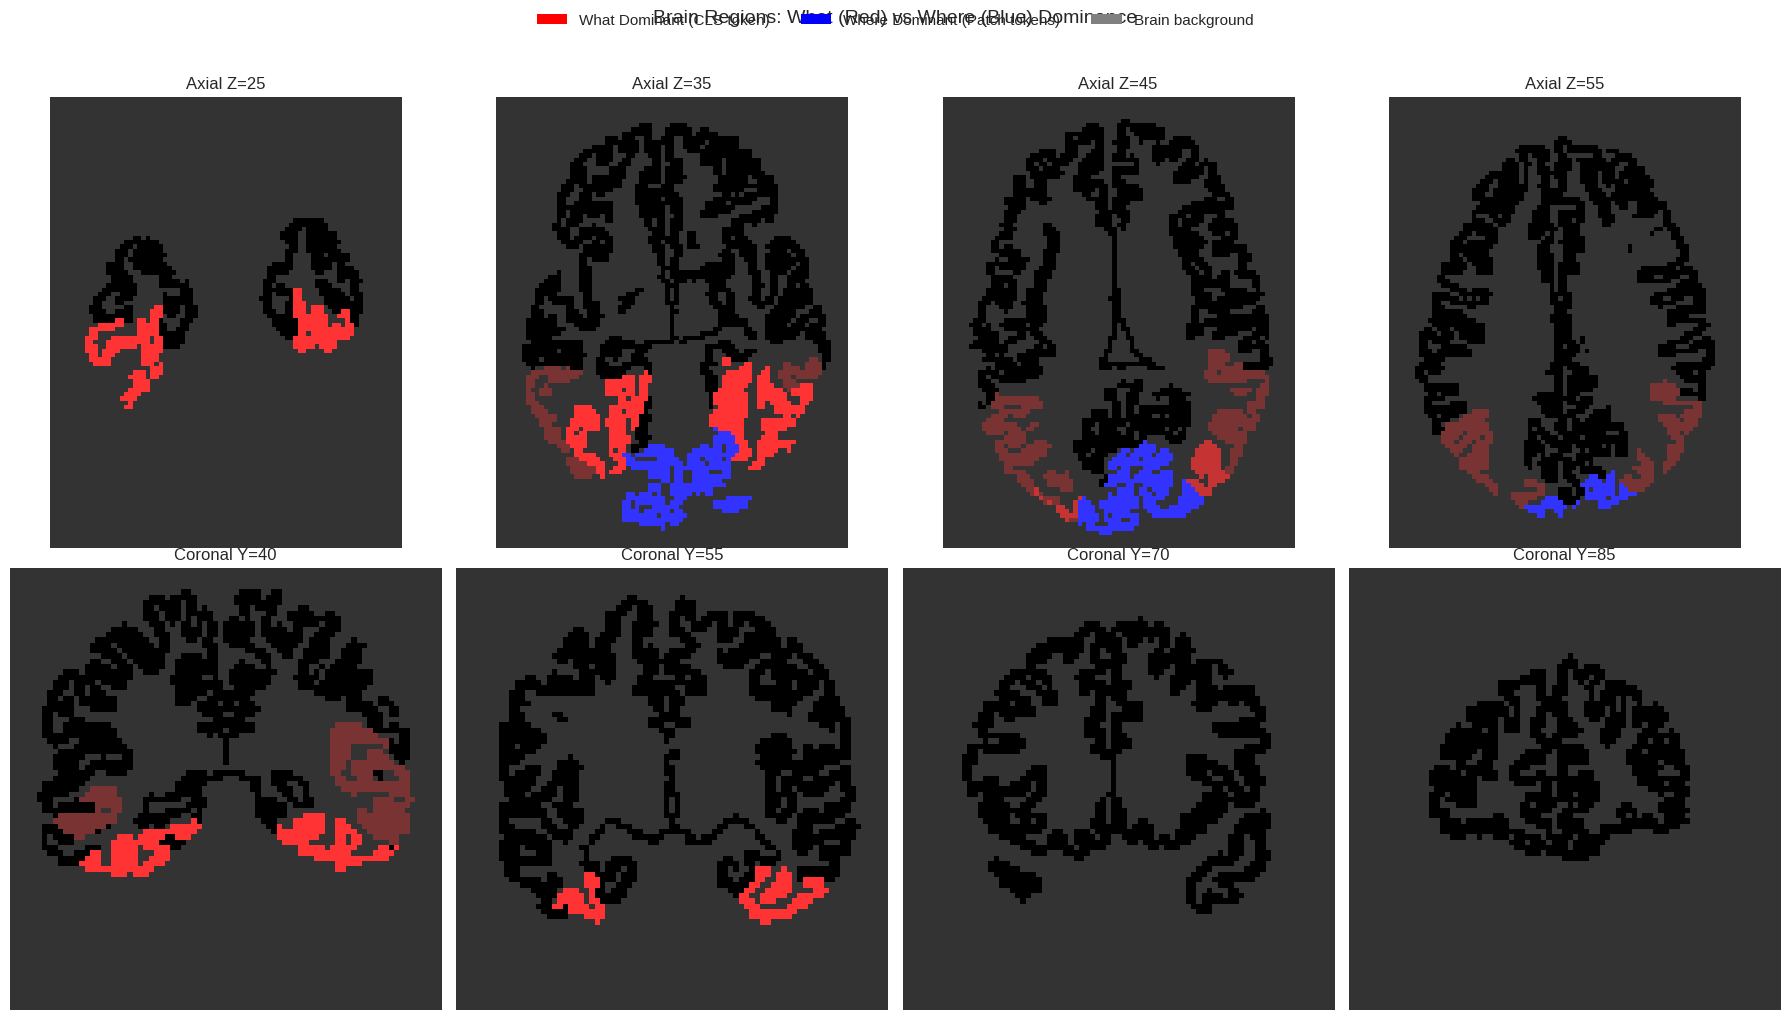

In [11]:
# Visualize What (Red) vs Where (Blue) on brain slices
fig, axes = plt.subplots(2, 4, figsize=(18, 10), facecolor='white')

# Brain mask for background
brain_mask = (streams_data != 0).astype(float)

# Normalize volumes for visualization
what_norm = what_volume / max(what_volume.max(), 0.001)
where_norm = where_volume / max(where_volume.max(), 0.001)

# Axial slices
z_slices = [25, 35, 45, 55]
for i, z in enumerate(z_slices):
    ax = axes[0, i]
    
    # Create RGB image
    h, w = what_volume[:, :, z].shape
    rgb = np.zeros((h, w, 3))
    
    # Red channel - What regions
    rgb[:, :, 0] = what_norm[:, :, z] * 1.0
    # Blue channel - Where regions
    rgb[:, :, 2] = where_norm[:, :, z] * 1.0
    
    # Add gray brain background
    bg = brain_mask[:, :, z] * 0.2
    for c in range(3):
        rgb[:, :, c] = np.maximum(rgb[:, :, c], bg)
    
    ax.imshow(rgb.transpose(1, 0, 2), origin='lower', aspect='equal')
    ax.set_title(f'Axial Z={z}', fontsize=12)
    ax.axis('off')

# Coronal and Sagittal views
y_slices = [40, 55, 70, 85]
for i, y in enumerate(y_slices):
    ax = axes[1, i]
    
    h, w = what_volume[:, y, :].shape
    rgb = np.zeros((h, w, 3))
    
    rgb[:, :, 0] = what_norm[:, y, :] * 1.0
    rgb[:, :, 2] = where_norm[:, y, :] * 1.0
    
    bg = brain_mask[:, y, :] * 0.2
    for c in range(3):
        rgb[:, :, c] = np.maximum(rgb[:, :, c], bg)
    
    ax.imshow(rgb.transpose(1, 0, 2), origin='lower', aspect='equal')
    ax.set_title(f'Coronal Y={y}', fontsize=12)
    ax.axis('off')

# Add legend
legend_elements = [
    Patch(facecolor='red', label='What Dominant (CLS token)'),
    Patch(facecolor='blue', label='Where Dominant (Patch tokens)'),
    Patch(facecolor='gray', label='Brain background')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=11)

plt.suptitle('Brain Regions: What (Red) vs Where (Blue) Dominance', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../docs/what_where_colored_regions.png', dpi=150, bbox_inches='tight')
plt.show()

IndexError: index 524 is out of bounds for axis 0 with size 524

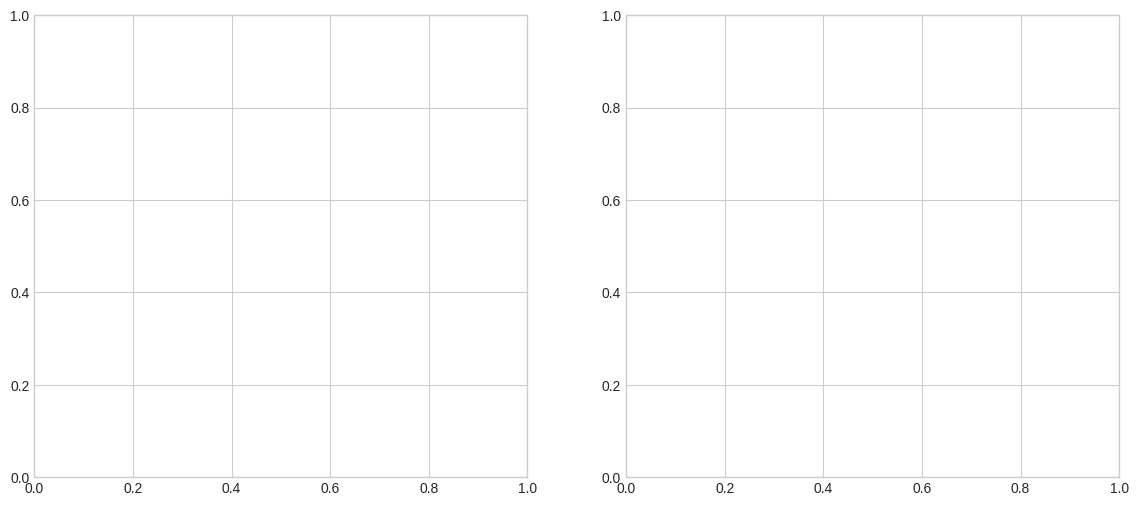

In [13]:
# Sample fMRI with What/Where regions colored
sample_idx = 0  # First sample

# Get sample fMRI
sample_gt = gt_subset[sample_idx]
sample_pred = all_pred[sample_idx]

# Create fMRI volumes (need flat_to_volume mapping)
# For now, show bar chart representation per stream
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Per-stream GT values
stream_gt_means = []
stream_pred_means = []
stream_names_list = []
stream_colors = []

for r in stream_results:
    sname = r['stream']
    voxels = stream_to_voxels[sname]
    stream_gt_means.append(sample_gt[voxels].mean())
    stream_pred_means.append(sample_pred[voxels].mean())
    stream_names_list.append(sname)
    stream_colors.append('red' if r['better'] == 'What' else 'blue')

x = np.arange(len(stream_names_list))
width = 0.35

# GT
ax = axes[0]
bars = ax.bar(x, stream_gt_means, color=stream_colors, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(stream_names_list, rotation=45, ha='right')
ax.set_ylabel('Mean fMRI Value')
ax.set_title(f'Sample #{sample_idx}: GT fMRI per Stream\n(Red=What region, Blue=Where region)')
ax.axhline(0, color='black', linewidth=0.5)

# Pred
ax = axes[1]
bars = ax.bar(x, stream_pred_means, color=stream_colors, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(stream_names_list, rotation=45, ha='right')
ax.set_ylabel('Mean fMRI Value')
ax.set_title(f'Sample #{sample_idx}: Pred fMRI per Stream\n(Red=What region, Blue=Where region)')
ax.axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../docs/sample_fmri_per_stream.png', dpi=150)
plt.show()

## 3. GT vs Pred fMRI on Anatomical Image

In [14]:
# Load flat-to-volume mapping
try:
    nsd_beta_path = '/mnt/HDD/dataset/NSD_raw/nsddata_betas/ppdata/subj01/func1pt8mm/betas_fithrf_GLMdenoise_RR/'
    # Load one beta file to get the mask
    beta_sample = nib.load(nsd_beta_path + 'betas_session01.nii.gz')
    beta_data = beta_sample.get_fdata()[:, :, :, 0]  # First trial
    
    # Create brain mask from beta data
    brain_mask_3d = ~np.isnan(beta_data) & (np.abs(beta_data) > 0)
    print(f"Beta shape: {beta_data.shape}")
    print(f"Brain mask voxels: {brain_mask_3d.sum()}")
except Exception as e:
    print(f"Could not load beta file: {e}")
    brain_mask_3d = streams_data != 0
    print(f"Using streams mask: {brain_mask_3d.sum()} voxels")

Beta shape: (81, 104, 83)
Brain mask voxels: 370174


In [15]:
# Load the flat-to-volume index mapping
# This maps flat fMRI indices to 3D volume coordinates
try:
    # Try to load precomputed mapping
    
    mapping_path = '../dataset/nsd/metadata/subj01_flat_to_volume.npz'
    flat_mapping = np.load(mapping_path)
    flat_indices = flat_mapping['indices']  # Shape: (15724, 3) - x, y, z coords
    print(f"Loaded flat-to-volume mapping: {flat_indices.shape}")
except:
    print("Creating flat-to-volume mapping from streams data...")
    # Get non-zero coordinates from streams (visual cortex mask)
    nonzero_coords = np.array(np.where(streams_data != 0)).T  # (N, 3)
    print(f"Non-zero coordinates in streams: {len(nonzero_coords)}")
    
    # Use first 15724 voxels
    if len(nonzero_coords) >= 15724:
        flat_indices = nonzero_coords[:15724]
    else:
        # Pad with zeros if needed
        flat_indices = np.zeros((15724, 3), dtype=int)
        flat_indices[:len(nonzero_coords)] = nonzero_coords
    
    print(f"Created mapping: {flat_indices.shape}")

Creating flat-to-volume mapping from streams data...
Non-zero coordinates in streams: 619750
Created mapping: (15724, 3)


In [16]:
def flat_to_volume(flat_fmri, flat_indices, volume_shape):
    """Convert flat fMRI array to 3D volume."""
    volume = np.zeros(volume_shape, dtype=np.float32)
    for i, (x, y, z) in enumerate(flat_indices):
        if i < len(flat_fmri):
            volume[x, y, z] = flat_fmri[i]
    return volume

# Test with sample
volume_shape = streams_data.shape
print(f"Volume shape: {volume_shape}")

Volume shape: (81, 104, 83)


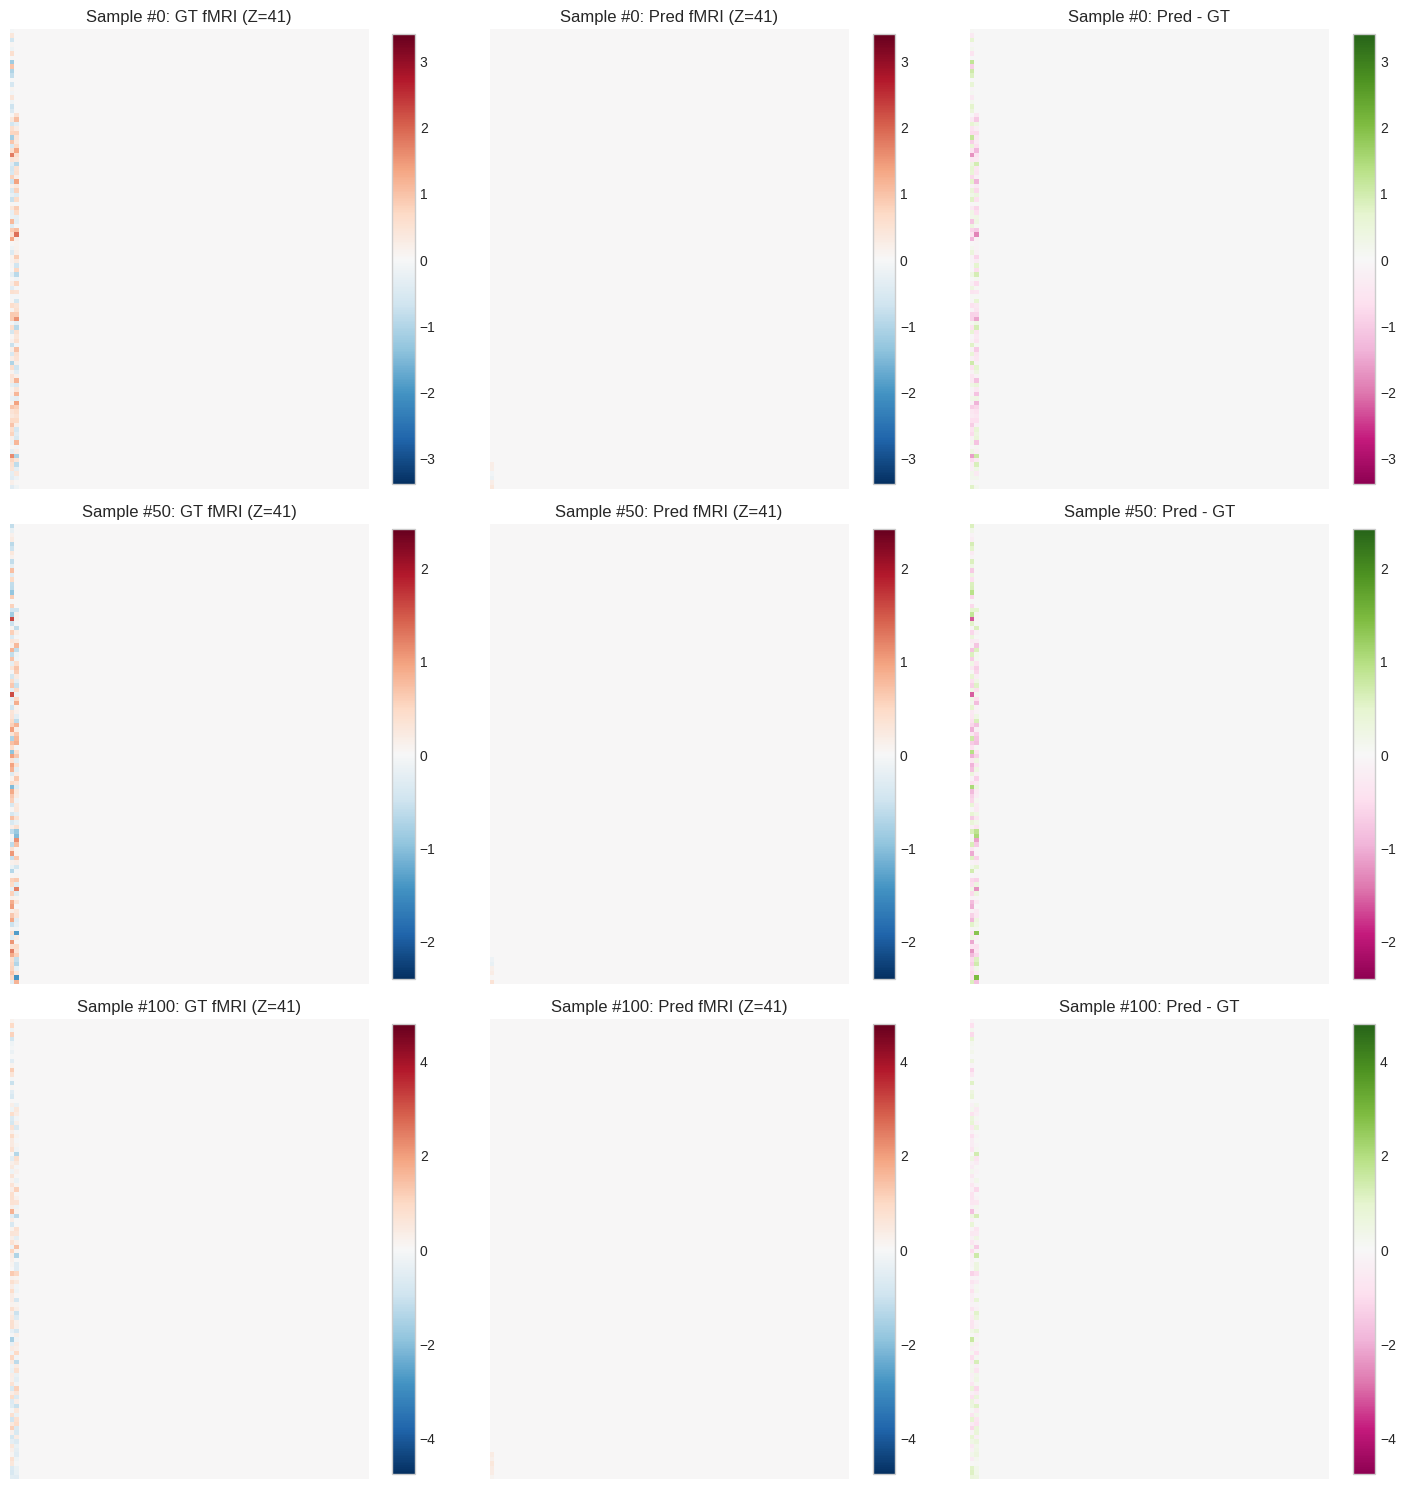

In [17]:
# Visualize GT and Pred fMRI for multiple samples
n_samples_to_show = 3
sample_indices = [0, 50, 100]  # Sample indices to visualize

fig, axes = plt.subplots(n_samples_to_show, 3, figsize=(15, 5*n_samples_to_show))

for row, sample_idx in enumerate(sample_indices):
    # Get fMRI data
    gt = gt_subset[sample_idx]
    pred = all_pred[sample_idx]
    
    # Convert to volumes
    gt_vol = flat_to_volume(gt, flat_indices, volume_shape)
    pred_vol = flat_to_volume(pred, flat_indices, volume_shape)
    
    # Find best slice (middle of active region)
    z_mid = volume_shape[2] // 2
    
    # Normalize for visualization
    vmax = max(np.abs(gt_vol).max(), np.abs(pred_vol).max())
    if vmax == 0:
        vmax = 1
    
    # GT fMRI
    ax = axes[row, 0]
    im = ax.imshow(gt_vol[:, :, z_mid].T, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
    ax.set_title(f'Sample #{sample_idx}: GT fMRI (Z={z_mid})')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # Pred fMRI
    ax = axes[row, 1]
    im = ax.imshow(pred_vol[:, :, z_mid].T, cmap='RdBu_r', vmin=-vmax, vmax=vmax, origin='lower')
    ax.set_title(f'Sample #{sample_idx}: Pred fMRI (Z={z_mid})')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
    
    # Difference
    ax = axes[row, 2]
    diff = pred_vol - gt_vol
    diff_max = np.abs(diff).max()
    if diff_max == 0:
        diff_max = 1
    im = ax.imshow(diff[:, :, z_mid].T, cmap='PiYG', vmin=-diff_max, vmax=diff_max, origin='lower')
    ax.set_title(f'Sample #{sample_idx}: Pred - GT')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig('../docs/gt_vs_pred_fmri.png', dpi=150)
plt.show()

## 4. Overlap Visualization: Purple (Match) vs Green (Miss)

In [18]:
def create_overlap_visualization(gt_vol, pred_vol, threshold_percentile=75):
    """
    Create overlap visualization:
    - Purple: Both GT and Pred are active (overlap)
    - Green: Only GT active (miss - pred didn't capture)
    - Orange: Only Pred active (false positive)
    - Gray: Neither active
    """
    # Threshold to get "active" voxels
    gt_threshold = np.percentile(np.abs(gt_vol[gt_vol != 0]), threshold_percentile) if (gt_vol != 0).any() else 0
    pred_threshold = np.percentile(np.abs(pred_vol[pred_vol != 0]), threshold_percentile) if (pred_vol != 0).any() else 0
    
    gt_active = np.abs(gt_vol) > gt_threshold
    pred_active = np.abs(pred_vol) > pred_threshold
    
    # Create RGB volume
    h, w, d = gt_vol.shape
    rgb_volume = np.zeros((h, w, d, 3), dtype=np.float32)
    
    # Overlap (both active) - Purple (Red + Blue)
    overlap = gt_active & pred_active
    rgb_volume[overlap, 0] = 0.8  # Red
    rgb_volume[overlap, 2] = 0.8  # Blue
    
    # GT only (miss) - Green
    gt_only = gt_active & ~pred_active
    rgb_volume[gt_only, 1] = 0.8  # Green
    
    # Pred only (false positive) - Orange
    pred_only = ~gt_active & pred_active
    rgb_volume[pred_only, 0] = 1.0  # Red
    rgb_volume[pred_only, 1] = 0.5  # Green (makes orange)
    
    return rgb_volume, overlap.sum(), gt_only.sum(), pred_only.sum()

print("Overlap visualization function ready")

Overlap visualization function ready


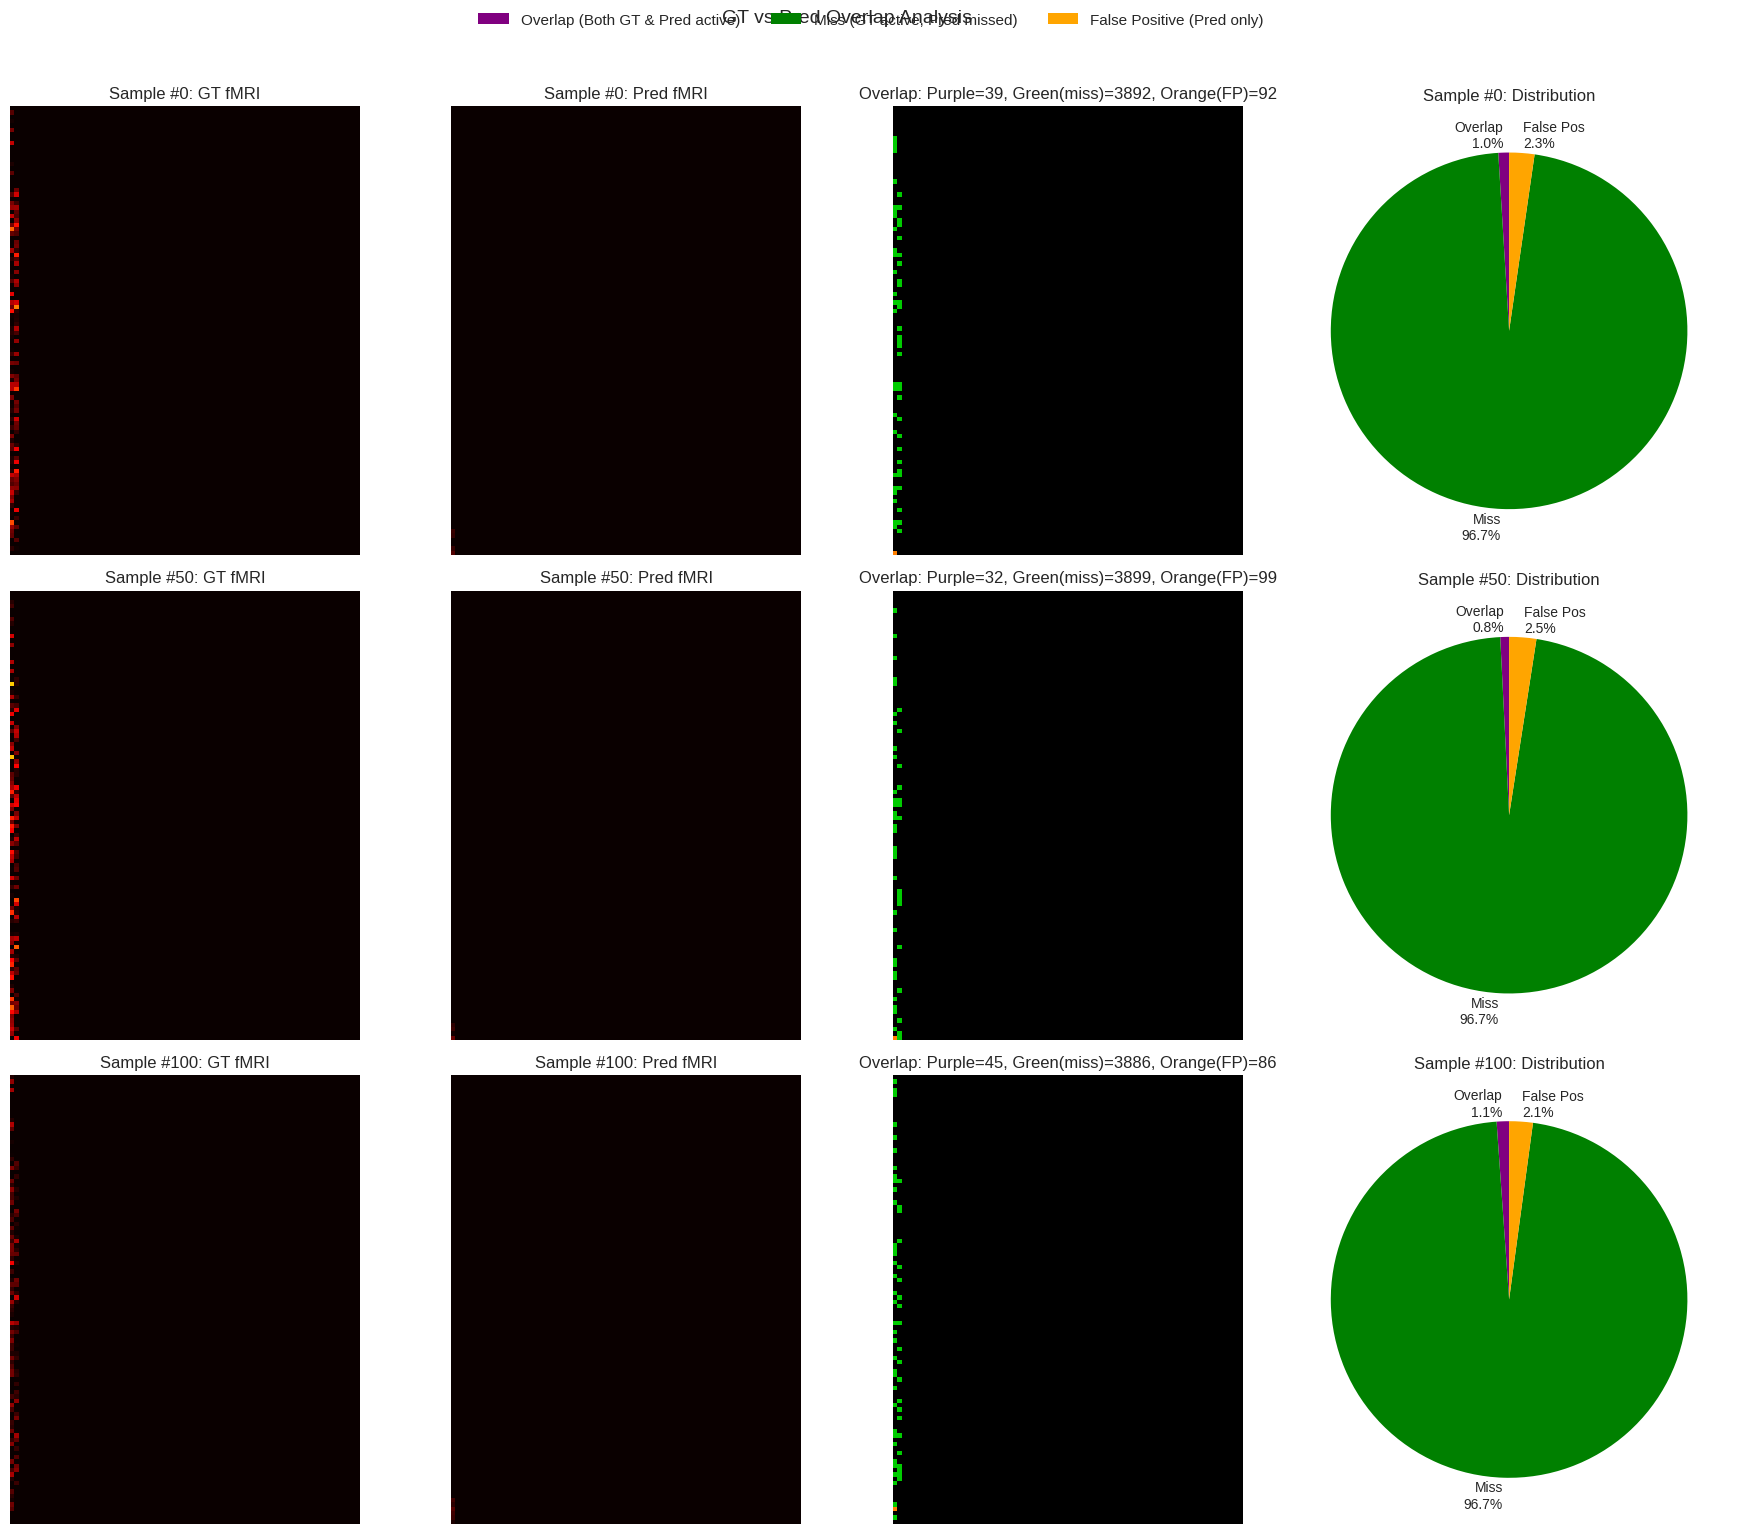

In [19]:
# Visualize overlap for multiple samples
sample_indices = [0, 50, 100]

fig, axes = plt.subplots(len(sample_indices), 4, figsize=(18, 5*len(sample_indices)))

for row, sample_idx in enumerate(sample_indices):
    gt = gt_subset[sample_idx]
    pred = all_pred[sample_idx]
    
    gt_vol = flat_to_volume(gt, flat_indices, volume_shape)
    pred_vol = flat_to_volume(pred, flat_indices, volume_shape)
    
    # Create overlap visualization
    rgb_vol, n_overlap, n_gt_only, n_pred_only = create_overlap_visualization(gt_vol, pred_vol)
    
    z_mid = volume_shape[2] // 2
    vmax = max(np.abs(gt_vol).max(), np.abs(pred_vol).max())
    if vmax == 0:
        vmax = 1
    
    # GT
    ax = axes[row, 0]
    ax.imshow(gt_vol[:, :, z_mid].T, cmap='hot', vmin=0, vmax=vmax, origin='lower')
    ax.set_title(f'Sample #{sample_idx}: GT fMRI')
    ax.axis('off')
    
    # Pred
    ax = axes[row, 1]
    ax.imshow(pred_vol[:, :, z_mid].T, cmap='hot', vmin=0, vmax=vmax, origin='lower')
    ax.set_title(f'Sample #{sample_idx}: Pred fMRI')
    ax.axis('off')
    
    # Overlap visualization
    ax = axes[row, 2]
    ax.imshow(rgb_vol[:, :, z_mid].transpose(1, 0, 2), origin='lower')
    ax.set_title(f'Overlap: Purple={n_overlap}, Green(miss)={n_gt_only}, Orange(FP)={n_pred_only}')
    ax.axis('off')
    
    # Overlap percentage
    ax = axes[row, 3]
    total_active = n_overlap + n_gt_only + n_pred_only
    if total_active > 0:
        overlap_pct = n_overlap / total_active * 100
        miss_pct = n_gt_only / total_active * 100
        fp_pct = n_pred_only / total_active * 100
    else:
        overlap_pct = miss_pct = fp_pct = 0
    
    colors = ['purple', 'green', 'orange']
    sizes = [overlap_pct, miss_pct, fp_pct]
    labels = [f'Overlap\n{overlap_pct:.1f}%', f'Miss\n{miss_pct:.1f}%', f'False Pos\n{fp_pct:.1f}%']
    
    ax.pie(sizes, labels=labels, colors=colors, autopct='', startangle=90)
    ax.set_title(f'Sample #{sample_idx}: Distribution')

# Add legend
legend_elements = [
    Patch(facecolor='purple', label='Overlap (Both GT & Pred active)'),
    Patch(facecolor='green', label='Miss (GT active, Pred missed)'),
    Patch(facecolor='orange', label='False Positive (Pred only)')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=11)

plt.suptitle('GT vs Pred Overlap Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../docs/gt_pred_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

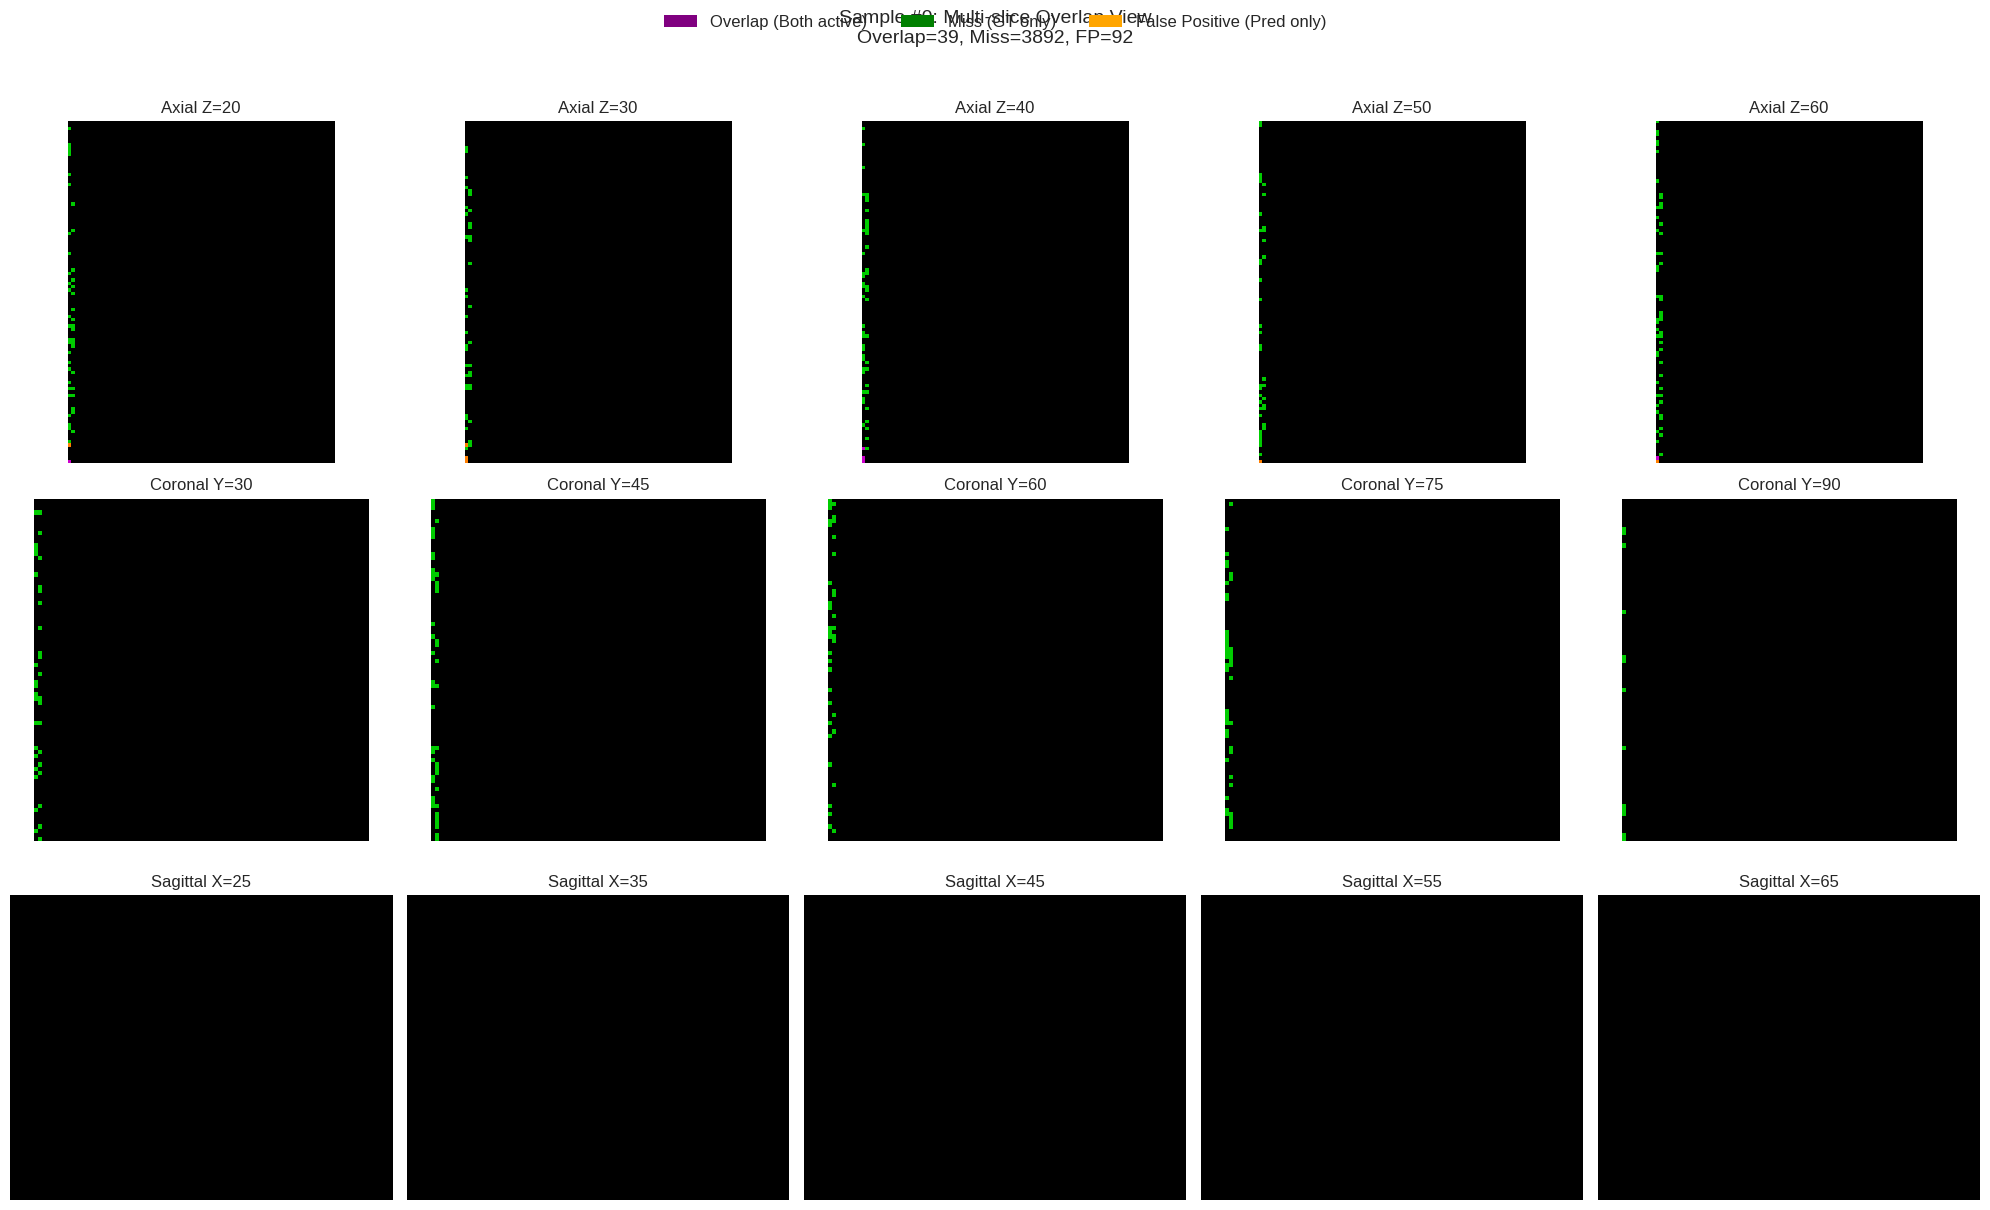

In [20]:
# Multi-slice overlap view for a single sample
sample_idx = 0

gt = gt_subset[sample_idx]
pred = all_pred[sample_idx]

gt_vol = flat_to_volume(gt, flat_indices, volume_shape)
pred_vol = flat_to_volume(pred, flat_indices, volume_shape)

rgb_vol, n_overlap, n_gt_only, n_pred_only = create_overlap_visualization(gt_vol, pred_vol)

# Show multiple slices
fig, axes = plt.subplots(3, 5, figsize=(20, 12))

# Axial slices
z_slices = [20, 30, 40, 50, 60]
for i, z in enumerate(z_slices):
    ax = axes[0, i]
    ax.imshow(rgb_vol[:, :, z].transpose(1, 0, 2), origin='lower')
    ax.set_title(f'Axial Z={z}')
    ax.axis('off')

# Coronal slices
y_slices = [30, 45, 60, 75, 90]
for i, y in enumerate(y_slices):
    ax = axes[1, i]
    ax.imshow(rgb_vol[:, y, :].transpose(1, 0, 2), origin='lower')
    ax.set_title(f'Coronal Y={y}')
    ax.axis('off')

# Sagittal slices
x_slices = [25, 35, 45, 55, 65]
for i, x in enumerate(x_slices):
    ax = axes[2, i]
    ax.imshow(rgb_vol[x, :, :].transpose(1, 0, 2), origin='lower')
    ax.set_title(f'Sagittal X={x}')
    ax.axis('off')

# Legend
legend_elements = [
    Patch(facecolor='purple', label='Overlap (Both active)'),
    Patch(facecolor='green', label='Miss (GT only)'),
    Patch(facecolor='orange', label='False Positive (Pred only)')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=12)

plt.suptitle(f'Sample #{sample_idx}: Multi-slice Overlap View\n'
             f'Overlap={n_overlap}, Miss={n_gt_only}, FP={n_pred_only}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../docs/overlap_multislice.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Per-stream overlap analysis
print("Per-Stream Overlap Analysis")
print("="*70)

# Average over all samples
stream_overlap_stats = {}

for sname, voxels in stream_to_voxels.items():
    if len(voxels) == 0:
        continue
    
    overlaps = []
    misses = []
    fps = []
    
    for i in range(min(50, num_samples)):  # Use first 50 samples
        gt_stream = gt_subset[i, voxels]
        pred_stream = all_pred[i, voxels]
        
        # Threshold
        gt_thresh = np.percentile(np.abs(gt_stream), 75)
        pred_thresh = np.percentile(np.abs(pred_stream), 75)
        
        gt_active = np.abs(gt_stream) > gt_thresh
        pred_active = np.abs(pred_stream) > pred_thresh
        
        overlap = (gt_active & pred_active).sum()
        miss = (gt_active & ~pred_active).sum()
        fp = (~gt_active & pred_active).sum()
        
        total = overlap + miss + fp
        if total > 0:
            overlaps.append(overlap / total)
            misses.append(miss / total)
            fps.append(fp / total)
    
    stream_overlap_stats[sname] = {
        'overlap': np.mean(overlaps) * 100,
        'miss': np.mean(misses) * 100,
        'fp': np.mean(fps) * 100
    }

# Print results
for sname, stats in stream_overlap_stats.items():
    r = stream_to_result.get(sname, {})
    dom = "What" if r.get('better') == 'What' else "Where"
    print(f"{sname:<12} ({dom:>5}): Overlap={stats['overlap']:5.1f}%, Miss={stats['miss']:5.1f}%, FP={stats['fp']:5.1f}%")

Per-Stream Overlap Analysis


IndexError: index 2732 is out of bounds for axis 1 with size 524

In [ ]:
# Visualize per-stream overlap
fig, ax = plt.subplots(figsize=(12, 6))

streams_sorted = list(stream_overlap_stats.keys())
overlaps = [stream_overlap_stats[s]['overlap'] for s in streams_sorted]
misses = [stream_overlap_stats[s]['miss'] for s in streams_sorted]
fps = [stream_overlap_stats[s]['fp'] for s in streams_sorted]

x = np.arange(len(streams_sorted))
width = 0.25

bars1 = ax.bar(x - width, overlaps, width, label='Overlap', color='purple', alpha=0.8)
bars2 = ax.bar(x, misses, width, label='Miss (GT only)', color='green', alpha=0.8)
bars3 = ax.bar(x + width, fps, width, label='False Positive', color='orange', alpha=0.8)

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xlabel('Brain Stream', fontsize=12)
ax.set_title('Per-Stream Overlap Analysis: GT vs Pred', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(streams_sorted, fontsize=11)
ax.legend()
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('../docs/per_stream_overlap.png', dpi=150)
plt.show()

## 5. Matplotlib Analysis Summary

In [ ]:
print("="*70)
print("VISUALIZATION SUMMARY")
print("="*70)

print("\n1. What/Where Dominance per Stream:")
for r in stream_results:
    color = "RED" if r['better'] == 'What' else "BLUE"
    print(f"   {r['stream']:<12}: {color:<5} ({r['better']}) - diff={r['diff']:+.4f}")

print("\n2. Per-Stream Overlap Statistics:")
for sname, stats in stream_overlap_stats.items():
    print(f"   {sname:<12}: Overlap={stats['overlap']:.1f}%, Miss={stats['miss']:.1f}%, FP={stats['fp']:.1f}%")

print("\n3. Color Legend:")
print("   - RED:    What-dominant regions (CLS token)")
print("   - BLUE:   Where-dominant regions (Patch tokens)")
print("   - PURPLE: GT & Pred both active (overlap)")
print("   - GREEN:  GT active only (miss)")
print("   - ORANGE: Pred active only (false positive)")

print("\n" + "="*70)

## 6. Pycortex 3D Visualization

Visualize fMRI data on 3D cortical surface using Pycortex.

In [ ]:
import cortex
import cortex.quickflat

# Check available subjects
db = cortex.database.db
print(f"Available subjects: {list(db.subjects.keys())}")

# Use subj01 from pycortex database
SUBJECT = 'subj01'
print(f"Using subject: {SUBJECT}")

In [ ]:
# Get the transform name for this subject
try:
    transforms = cortex.database.db.get_xfms(SUBJECT)
    print(f"Available transforms for {SUBJECT}: {transforms}")
    TRANSFORM = transforms[0] if transforms else 'func1pt8mm'
except:
    TRANSFORM = 'func1pt8mm'
    print(f"Using default transform: {TRANSFORM}")

In [ ]:
# Create Pycortex Volume from What/Where dominance data
# dominance_volume: positive = What dominant (red), negative = Where dominant (blue)

# Create pycortex Volume object
dominance_vol = cortex.Volume(
    dominance_volume.T,  # Pycortex expects (z, y, x) order
    subject=SUBJECT,
    xfmname=TRANSFORM,
    cmap='RdBu_r',
    vmin=-0.05,
    vmax=0.05
)

print(f"Created dominance volume for pycortex")
print(f"Shape: {dominance_volume.shape} -> {dominance_volume.T.shape}")

In [ ]:
# Generate flatmap visualization for What/Where dominance
fig = cortex.quickflat.make_figure(
    dominance_vol,
    with_curvature=True,
    with_rois=False,
    with_sulci=True,
    with_colorbar=True,
    height=1024
)

plt.title('What (Red) vs Where (Blue) Dominance - Cortical Flatmap', fontsize=14)
plt.savefig('../docs/pycortex_what_where_flatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Create RGB pycortex volume for What (Red) vs Where (Blue)
# Normalize to 0-1 range
what_normalized = what_volume / max(what_volume.max(), 0.001)
where_normalized = where_volume / max(where_volume.max(), 0.001)

rgb_vol = cortex.VolumeRGB(
    red=what_normalized.T,
    green=np.zeros_like(what_normalized.T),
    blue=where_normalized.T,
    subject=SUBJECT,
    xfmname=TRANSFORM,
    alpha=np.maximum(what_normalized.T, where_normalized.T)  # Alpha based on activity
)

fig = cortex.quickflat.make_figure(
    rgb_vol,
    with_curvature=True,
    with_rois=False,
    with_sulci=True,
    height=1024
)

plt.title('What (Red) vs Where (Blue) - RGB Flatmap', fontsize=14)
plt.savefig('../docs/pycortex_what_where_rgb.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Visualize GT vs Pred fMRI on cortical surface
sample_idx = 0

gt = gt_subset[sample_idx]
pred = all_pred[sample_idx]

gt_vol = flat_to_volume(gt, flat_indices, volume_shape)
pred_vol = flat_to_volume(pred, flat_indices, volume_shape)

# Normalize
vmax = max(np.abs(gt_vol).max(), np.abs(pred_vol).max())
if vmax == 0:
    vmax = 1

# Create pycortex volumes
gt_cortex = cortex.Volume(
    gt_vol.T,
    subject=SUBJECT,
    xfmname=TRANSFORM,
    cmap='RdBu_r',
    vmin=-vmax,
    vmax=vmax
)

pred_cortex = cortex.Volume(
    pred_vol.T,
    subject=SUBJECT,
    xfmname=TRANSFORM,
    cmap='RdBu_r',
    vmin=-vmax,
    vmax=vmax
)

print(f"Sample {sample_idx}: GT and Pred volumes created")

In [ ]:
# GT flatmap
fig_gt = cortex.quickflat.make_figure(
    gt_cortex,
    with_curvature=True,
    with_rois=False,
    with_sulci=True,
    with_colorbar=True,
    height=800
)
plt.title(f'Sample #{sample_idx}: GT fMRI - Cortical Flatmap', fontsize=14)
plt.savefig('../docs/pycortex_gt_fmri.png', dpi=150, bbox_inches='tight')
plt.show()

# Pred flatmap
fig_pred = cortex.quickflat.make_figure(
    pred_cortex,
    with_curvature=True,
    with_rois=False,
    with_sulci=True,
    with_colorbar=True,
    height=800
)
plt.title(f'Sample #{sample_idx}: Pred fMRI - Cortical Flatmap', fontsize=14)
plt.savefig('../docs/pycortex_pred_fmri.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Overlap visualization on cortical surface
# Purple = overlap, Green = miss, Orange = false positive

# Threshold for "active" voxels (75th percentile)
gt_thresh = np.percentile(np.abs(gt_vol[gt_vol != 0]), 75) if (gt_vol != 0).any() else 0
pred_thresh = np.percentile(np.abs(pred_vol[pred_vol != 0]), 75) if (pred_vol != 0).any() else 0

gt_active = np.abs(gt_vol) > gt_thresh
pred_active = np.abs(pred_vol) > pred_thresh

# Create RGB channels
overlap = gt_active & pred_active      # Purple (R+B)
gt_only = gt_active & ~pred_active     # Green
pred_only = ~gt_active & pred_active   # Orange (R+G*0.5)

red_channel = np.zeros_like(gt_vol, dtype=np.float32)
green_channel = np.zeros_like(gt_vol, dtype=np.float32)
blue_channel = np.zeros_like(gt_vol, dtype=np.float32)

# Purple for overlap
red_channel[overlap] = 0.8
blue_channel[overlap] = 0.8

# Green for miss
green_channel[gt_only] = 0.8

# Orange for false positive
red_channel[pred_only] = 1.0
green_channel[pred_only] = 0.5

print(f"Overlap: {overlap.sum()}, Miss: {gt_only.sum()}, FP: {pred_only.sum()}")

In [ ]:
# Create RGB pycortex volume for overlap visualization
alpha_channel = np.maximum(red_channel, np.maximum(green_channel, blue_channel))

overlap_rgb = cortex.VolumeRGB(
    red=red_channel.T,
    green=green_channel.T,
    blue=blue_channel.T,
    subject=SUBJECT,
    xfmname=TRANSFORM,
    alpha=alpha_channel.T
)

fig = cortex.quickflat.make_figure(
    overlap_rgb,
    with_curvature=True,
    with_rois=False,
    with_sulci=True,
    height=1024
)

plt.title(f'Sample #{sample_idx}: Overlap Analysis\n'
          f'Purple=Overlap, Green=Miss, Orange=False Positive', fontsize=14)
plt.savefig('../docs/pycortex_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Create dataset for interactive 3D WebGL viewer
dataset = cortex.Dataset(
    what_where_dominance=dominance_vol,
    gt_fmri=gt_cortex,
    pred_fmri=pred_cortex,
    overlap=overlap_rgb
)

print("Dataset created with views:")
print("  - what_where_dominance: Red=What, Blue=Where")
print("  - gt_fmri: Ground truth fMRI")
print("  - pred_fmri: Predicted fMRI")
print("  - overlap: Purple=match, Green=miss, Orange=FP")
print("\nTo launch interactive 3D viewer, uncomment and run:")
print("  cortex.webgl.show(dataset, open_browser=True, port=8050)")

In [ ]:
# Optional: Launch interactive 3D WebGL viewer
# This opens a WebGL viewer in your browser for interactive exploration

# Uncomment the line below to launch:
# cortex.webgl.show(dataset, open_browser=True, port=8050)

## 7. Summary

In [ ]:
print("="*70)
print("VISUALIZATION SUMMARY")
print("="*70)

print(f"\nPycortex Subject: {SUBJECT}")
print(f"Pycortex Transform: {TRANSFORM}")

print("\n1. What/Where Dominance per Stream:")
for r in stream_results:
    color = "RED" if r['better'] == 'What' else "BLUE"
    print(f"   {r['stream']:<12}: {color:<5} ({r['better']}) - diff={r['diff']:+.4f}")

print("\n2. Per-Stream Overlap Statistics:")
for sname, stats in stream_overlap_stats.items():
    print(f"   {sname:<12}: Overlap={stats['overlap']:.1f}%, Miss={stats['miss']:.1f}%, FP={stats['fp']:.1f}%")

print("\n3. Generated Visualizations:")
print("   Matplotlib:")
print("     - what_where_colored_regions.png")
print("     - sample_fmri_per_stream.png")
print("     - gt_vs_pred_fmri.png")
print("     - gt_pred_overlap.png")
print("     - overlap_multislice.png")
print("     - per_stream_overlap.png")
print("   Pycortex:")
print("     - pycortex_what_where_flatmap.png")
print("     - pycortex_what_where_rgb.png")
print("     - pycortex_gt_fmri.png")
print("     - pycortex_pred_fmri.png")
print("     - pycortex_overlap.png")

print("\n4. Color Legend:")
print("   What/Where Maps:")
print("     RED:    What-dominant (CLS token)")
print("     BLUE:   Where-dominant (Patch tokens)")
print("   Overlap Analysis:")
print("     PURPLE: Both GT & Pred active")
print("     GREEN:  GT only (model missed)")
print("     ORANGE: Pred only (false positive)")

print("\n5. Interactive 3D Viewer:")
print("   Run: cortex.webgl.show(dataset, open_browser=True)")

print("\n" + "="*70)